# The Future of Intelligent Measurement
### *Modern Strain Gage Technology* — Companion Notebook

Companion notebook to Chapter 65 — The Future of Intelligent Measurement.

*The sensors are ready and the physics is understood; what remains is building systems intelligent enough to extract the full value of a signal we already receive.*

The bonded foil strain gage was invented in 1938. In the eight decades since, the fundamental physics has not changed — Wheatstone bridges still balance, gage factors still hover near 2.0, and the challenge of bonding a fragile foil grid to a structural surface is still solved with patience and clean technique. What has changed is everything built on top of that signal: the speed and resolution of the acquisition, the statistical rigor of the uncertainty analysis, and increasingly, the intelligence of the interpretation.

The technology readiness matrix in this notebook plots twelve technologies against two axes: readiness (TRL 1 = concept only, TRL 10 = fully deployed at scale) and potential impact on strain measurement practice. Mature technologies — bonded foil gages and 24-bit digital DAQ — sit at high readiness with proven high impact. Emerging technologies — wireless telemetry, ML anomaly detection, distributed fiber-optic sensing — are well past proof-of-concept and entering routine use. Early-stage technologies — physics-informed neural networks, self-calibrating systems, digital twins, AI-driven test planning — carry high potential impact but require substantial development before they can be trusted in safety-critical applications.

The most important observation is not where any individual technology sits, but the pattern: every technology in the early-stage, high-impact quadrant is a software or intelligence technology, not a physical sensing technology. The sensors are ready. The physics is understood. The challenge that remains is building systems intelligent enough to extract the full value of the signal they already receive.

**This notebook demonstrates:**
1. The technology readiness vs. impact landscape — twelve strain measurement technologies positioned on a 2D readiness–impact chart (the figure the chapter prints as Figure 65.2).

In [1]:
# Colab setup: uncomment to install dependencies
# !pip install matplotlib

from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# Directory for the figure the chapter includes. Do not rename saved files —
# the book references this exact path.
OUT_DIR = Path("../src/media/ch65")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# This notebook is fully deterministic (a hand-curated landscape, no random data),
# so there is no randomness to seed.

---
## 1 — Technology Readiness vs. Impact: A Landscape View

Technology Readiness Levels (TRL) are a nine-point scale originally developed by NASA to characterize how mature a technology is: TRL 1 is a basic concept, TRL 9 is proven in an operational environment. The chart below extends this to a ten-point scale with TRL 10 representing widespread deployment at commercial scale.

The horizontal axis maps readiness; the vertical axis maps expected impact on strain measurement practice. Four color codes identify maturity bands: blue (mature, TRL ≥ 8), green (emerging, TRL 5–7), red (early-stage, TRL ≤ 5), and gray (future concept). The bonded foil gage and 24-bit DAQ anchor the upper-right corner — decades of deployment at global scale with transformative impact. Physics-informed neural networks and self-calibrating systems occupy the high-impact, low-readiness corner — promising but not yet ready for safety-critical deployment without extensive validation.

The dotted vertical line at TRL 5 marks the boundary where a technology transitions from primarily a research activity to primarily an engineering and deployment activity. Technologies left of this line are still being invented. Technologies right of it are being refined. The book has described the practice of the mature and emerging technologies in detail; the early-stage technologies mark where the next edition of this book will be written.

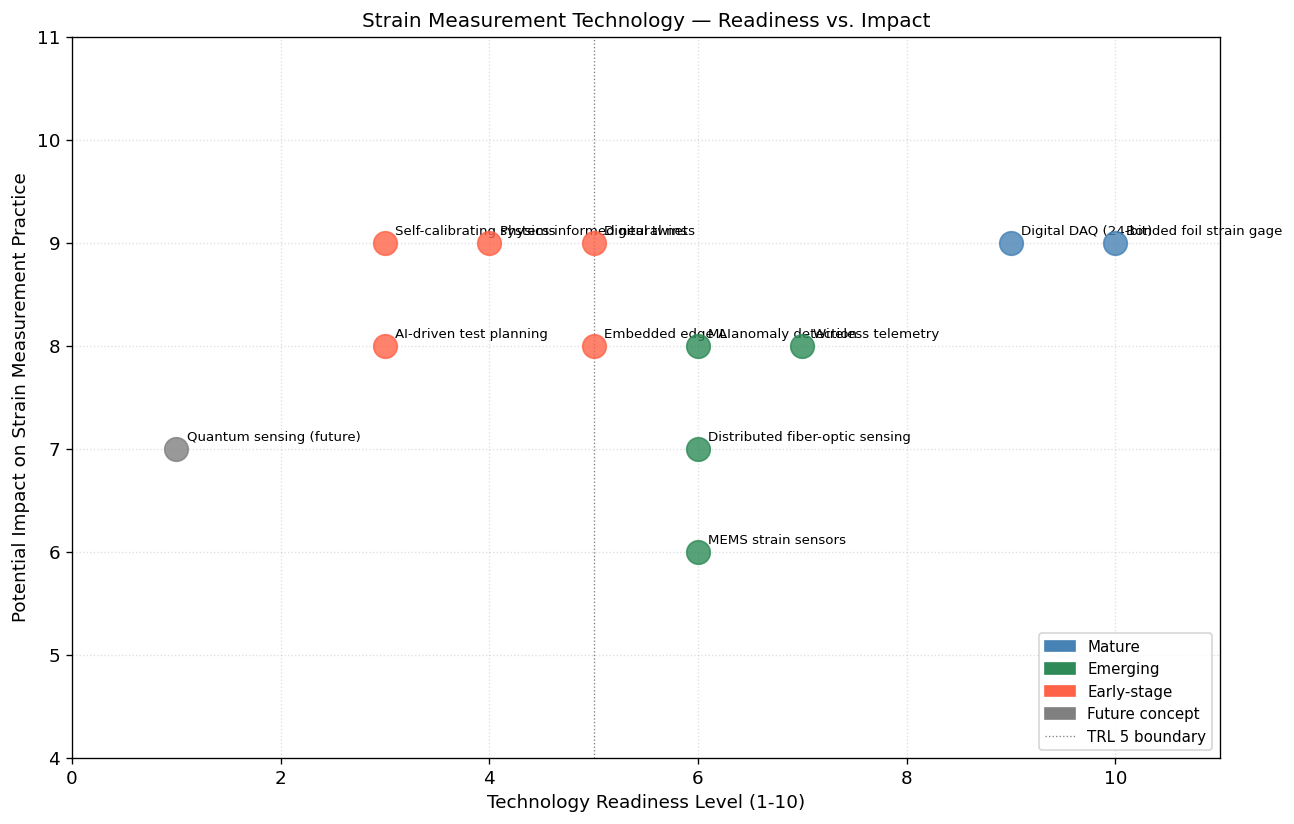

The foundations are fixed. The intelligence built on them is still being written.


In [2]:
# Technology readiness vs. impact matrix.
# Values are the author's subjective assessment at time of writing — a landscape
# sketch, not a precise ranking. Each technology is placed by (TRL, impact) and
# colored by its maturity band.

TRL_BOUNDARY = 5  # left of this line: still being invented; right: being refined

# Maturity-band colors
MATURE, EMERGING, EARLY, FUTURE = 'steelblue', 'seagreen', 'tomato', 'gray'

# name -> (technology readiness level, potential impact, maturity color)
TECHNOLOGIES = {
    'Bonded foil strain gage':         (10, 9, MATURE),
    'Digital DAQ (24-bit)':            (9,  9, MATURE),
    'Wireless telemetry':              (7,  8, EMERGING),
    'ML anomaly detection':            (6,  8, EMERGING),
    'Digital twins':                   (5,  9, EARLY),
    'Distributed fiber-optic sensing': (6,  7, EMERGING),
    'MEMS strain sensors':             (6,  6, EMERGING),
    'AI-driven test planning':         (3,  8, EARLY),
    'Self-calibrating systems':        (3,  9, EARLY),
    'Physics-informed neural nets':    (4,  9, EARLY),
    'Embedded edge AI':                (5,  8, EARLY),
    'Quantum sensing (future)':        (1,  7, FUTURE),
}


def plot_readiness_impact(technologies, boundary=TRL_BOUNDARY):
    """Scatter each technology by readiness (x) and potential impact (y).

    Point color encodes the maturity band; a vertical line at ``boundary``
    separates technologies still being invented (left) from those being
    refined (right). Returns the Matplotlib ``(fig, ax)``.
    """
    fig, ax = plt.subplots(figsize=(11, 7))
    for name, (trl, impact, color) in technologies.items():
        ax.scatter(trl, impact, s=200, color=color, alpha=0.8, zorder=5)
        ax.annotate(name, (trl, impact),
                    xytext=(trl + 0.1, impact + 0.08), fontsize=8)

    ax.axvline(boundary, color='gray', lw=0.8, linestyle=':')
    ax.set_xlabel('Technology Readiness Level (1-10)')
    ax.set_ylabel('Potential Impact on Strain Measurement Practice')
    ax.set_title('Strain Measurement Technology — Readiness vs. Impact')
    ax.set_xlim(0, 11)
    ax.set_ylim(4, 11)
    ax.grid(True, linestyle=':', alpha=0.4)

    legend_elements = [
        Patch(color=MATURE, label='Mature'),
        Patch(color=EMERGING, label='Emerging'),
        Patch(color=EARLY, label='Early-stage'),
        Patch(color=FUTURE, label='Future concept'),
        Line2D([0], [0], color='gray', lw=0.8, linestyle=':',
               label=f'TRL {boundary} boundary'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
    fig.tight_layout()
    return fig, ax


fig, ax = plot_readiness_impact(TECHNOLOGIES)
fig.savefig(OUT_DIR / 'fig65_nb1_technology_readiness_impact.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("The foundations are fixed. The intelligence built on them is still being written.")


## Where to take this next

This chart is a starting point, not a verdict. A few concrete ways to build on it:

- **Make the assessment your own.** The coordinates in `TECHNOLOGIES` are one engineer's snapshot. Re-rank a handful of entries for your own domain — a wind-farm operator and a prosthetics lab will not place *distributed fiber-optic sensing* at the same readiness — and watch the frontier shift.
- **Add the technologies the chapter discusses but the chart omits.** Chapter 65 develops *federated learning* and the *mature digital twin* at length; plot them alongside physics-informed neural nets and see whether they cluster in the same high-impact, low-readiness corner.
- **Turn the static snapshot into a trajectory.** Give each technology a projected TRL for 2030, draw an arrow from today's position to the projection, and let the figure argue about *direction* rather than just present position.
